<a href="https://colab.research.google.com/github/AbdulNaeemB/Lab-Assignments/blob/main/ML_Lab_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [ ]:
data = pd.read_csv('Housepriceprediction.csv')

In [ ]:
data.head()

,Id,LotArea,OverallQual,1stFlrSF,GrLivArea,TotRmsAbvGrd,GarageCars,GarageArea,SalePrice
0,1,8450,7,856,1710,8,2,548,208500
1,2,9600,6,1262,1262,6,2,460,181500
2,3,11250,7,920,1786,6,2,608,223500
3,4,9550,7,961,1717,7,3,642,140000
4,5,14260,8,1145,2198,9,3,836,250000


In [ ]:
data.describe()

,Id,LotArea,OverallQual,1stFlrSF,GrLivArea,TotRmsAbvGrd,GarageCars,GarageArea,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,10516.828082,6.099315,1162.626712,1515.463699,6.517808,1.767123,472.980137,180921.195890
std,421.610009,9981.264932,1.382997,386.587738,525.480383,1.625393,0.747315,213.804841,79442.502883
min,1.000000,1300.000000,1.000000,334.000000,334.000000,2.000000,0.000000,0.000000,34900.000000
25%,365.750000,7553.500000,5.000000,882.000000,1129.500000,5.000000,1.000000,334.500000,129975.000000
50%,730.500000,9478.500000,6.000000,1087.000000,1464.000000,6.000000,2.000000,480.000000,163000.000000
75%,1095.250000,11601.500000,7.000000,1391.250000,1776.750000,7.000000,2.000000,576.000000,214000.000000
max,1460.000000,215245.000000,10.000000,4692.000000,5642.000000,14.000000,4.000000,1418.000000,755000.000000


In [ ]:
data.isnull().sum()

,0
Id,0
LotArea,0
OverallQual,0
1stFlrSF,0
GrLivArea,0
TotRmsAbvGrd,0
GarageCars,0
GarageArea,0
SalePrice,0


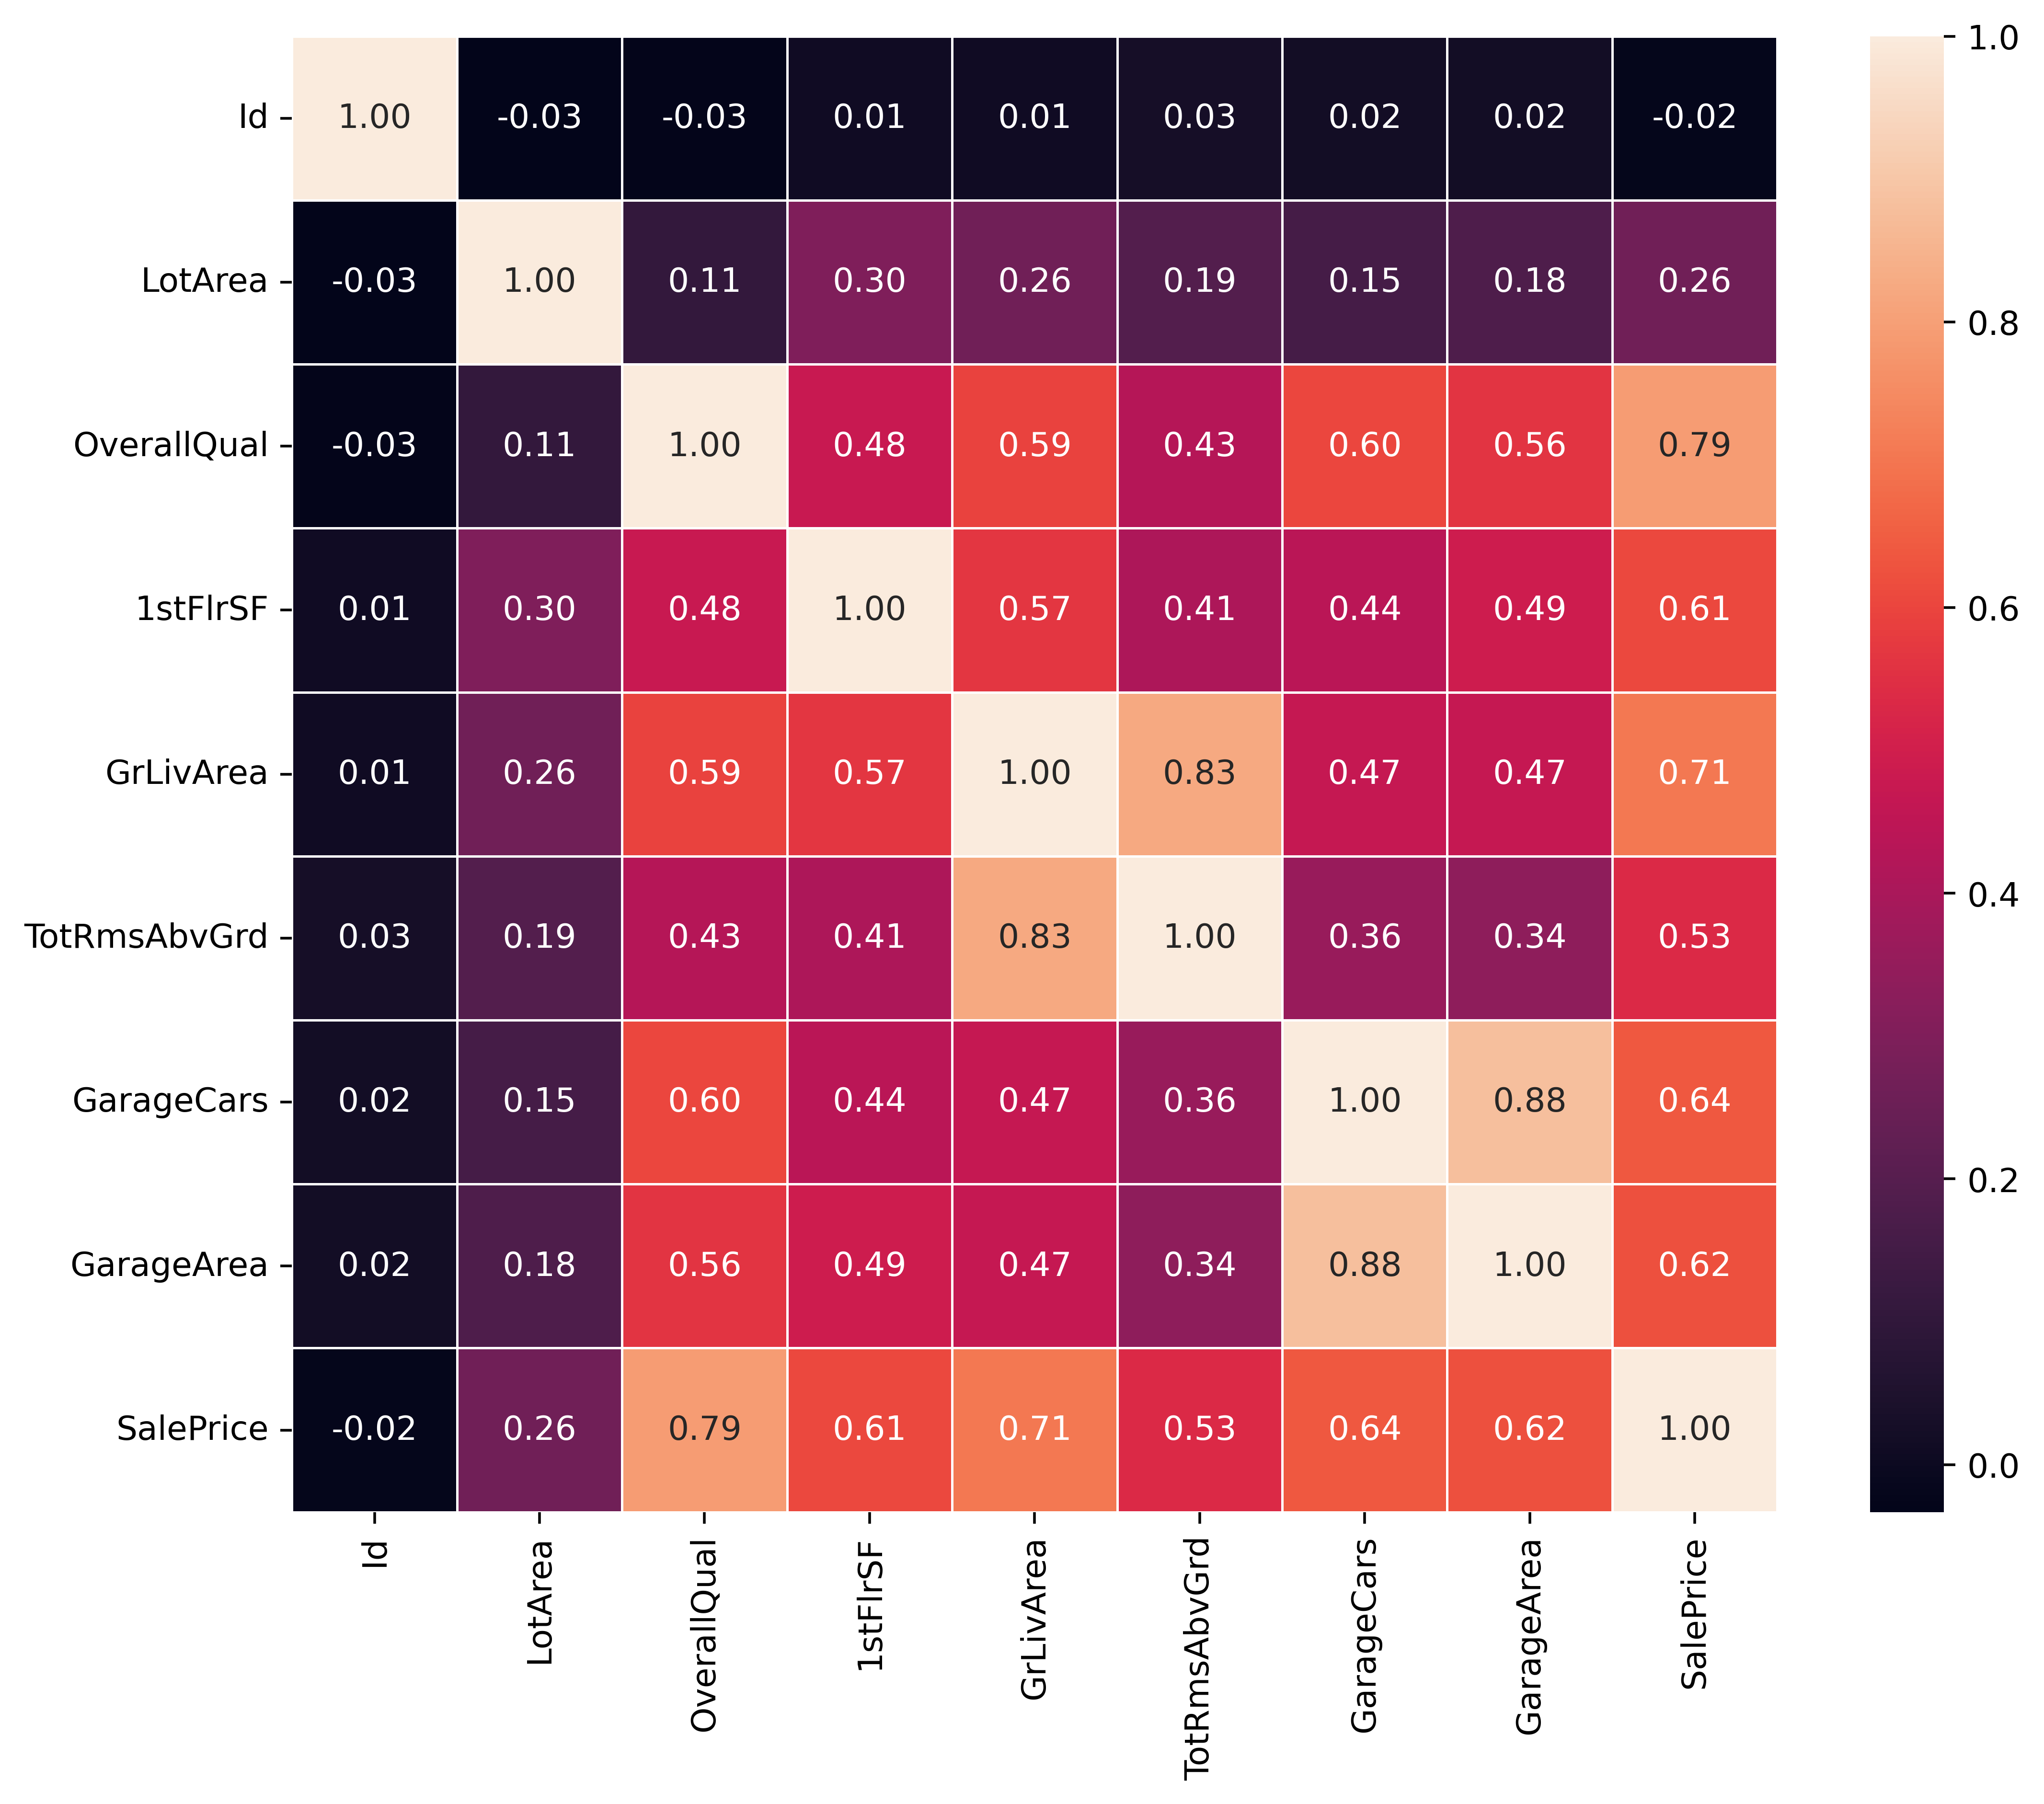

In [ ]:
corr = data.corr(method='pearson')
plt.figure(figsize=(10,8), dpi =500)
sns.heatmap(corr,annot=True,fmt=".2f", linewidth=.5)
plt.show()

In [ ]:
features = ['LotArea', 'OverallQual', '1stFlrSF', 'GrLivArea', 'TotRmsAbvGrd', 'GarageCars', 'GarageArea']

target = 'SalePrice'

In [ ]:
X = data[features].values
y = data[target].values / 1000.0

In [ ]:
X

array([[ 8450,     7,   856, ...,     8,     2,   548],
       [ 9600,     6,  1262, ...,     6,     2,   460],
       [11250,     7,   920, ...,     6,     2,   608],
       ...,
       [ 9042,     7,  1188, ...,     9,     1,   252],
       [ 9717,     5,  1078, ...,     5,     1,   240],
       [ 9937,     5,  1256, ...,     6,     1,   276]])

In [ ]:
X.ndim

2

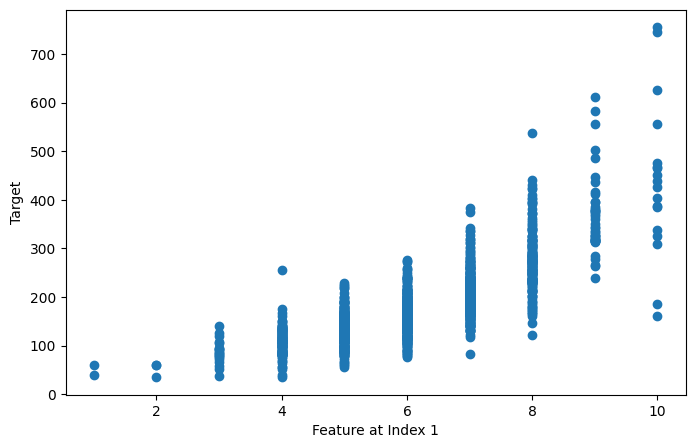

In [ ]:
plt.subplots(figsize=(8, 5))
plt.scatter(X[:, 1], y, marker='o')
plt.xlabel("Feature at Index 1")
plt.ylabel("Target")
plt.show()

[-1.07805456e+02  6.17664983e-04  2.64238353e+01  2.82589672e-02
  4.12356858e-02 -1.09884207e+00  1.36122815e+01  1.86585542e-02]


In [ ]:
def normalize_features(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    return (X - mu) / sigma, mu, sigma

In [ ]:
X_norm, mu_X, sigma_X = normalize_features(X)
X_norm = np.c_[np.ones(X_norm.shape[0]), X_norm]

In [ ]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X_norm, y, test_size=0.3, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

In [ ]:
def compute_cost(X, y, theta, lambda_reg=0):
    m = len(y)
    predictions = X.dot(theta)
    cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    reg_cost = (lambda_reg / (2 * m)) * np.sum(theta[1:] ** 2)
    return cost + reg_cost

In [ ]:
def gradient_descent_with_momentum(X, y, X_val, y_val, theta, learning_rate, iterations, lambda_reg=0, early_stop_patience=100):
    m = len(y)
    cost_history = []
    val_cost_history = []

    velocity = np.zeros_like(theta)
    momentum = 0.9
    best_theta = theta
    best_val_cost = float('inf')
    patience = 0

    for i in range(iterations):
        predictions = X.dot(theta)
        errors = predictions - y
        gradients = (1 / m) * X.T.dot(errors) + (lambda_reg / m) * np.r_[0, theta[1:]]

        velocity = momentum * velocity + learning_rate * gradients
        theta = theta - velocity

        cost = compute_cost(X, y, theta, lambda_reg)
        cost_history.append(cost)
        val_cost = compute_cost(X_val, y_val, theta, lambda_reg)
        val_cost_history.append(val_cost)

        if i % 100 == 0:
            print(f"Iteration {i}: Train Cost = {cost:.4f}, Val Cost = {val_cost:.4f}")

        if val_cost < best_val_cost:
            best_val_cost = val_cost
            best_theta = theta.copy()
            patience = 0
        else:
            patience += 1
            if patience > early_stop_patience:
                print(f"Early stopping at iteration {i}. Best validation cost: {best_val_cost:.4f}")
                break

    return best_theta, cost_history, val_cost_history


In [ ]:
theta_initial = np.zeros(X_train.shape[1])
learning_rate = 0.01
iterations = 5000
lambda_reg = 0.01

theta_final, train_cost_hist, val_cost_hist = gradient_descent_with_momentum(
    X_train, y_train, X_val, y_val, theta_initial, learning_rate, iterations, lambda_reg
)

Iteration 0: Train Cost = 18976.5468, Val Cost = 18807.2050
Iteration 100: Train Cost = 786.9585, Val Cost = 677.5461
Early stopping at iteration 124. Best validation cost: 650.6668


In [ ]:
print("Optimized Theta:", theta_final)
print("Final training cost:", train_cost_hist[-1])
print("Final validation cost:", val_cost_hist[-1])


Optimized Theta: [182.22391829   6.12373999  29.13541949  11.12778666  16.33521403
   4.36129223  13.93734536  11.12169128]
Final training cost: 786.3601448833062
Final validation cost: 676.1127334672035


In [ ]:
test_cost = compute_cost(X_test, y_test, theta_final, lambda_reg)
print("\nTest cost (MSE):", test_cost)


Test cost (MSE): 758.3631802206058


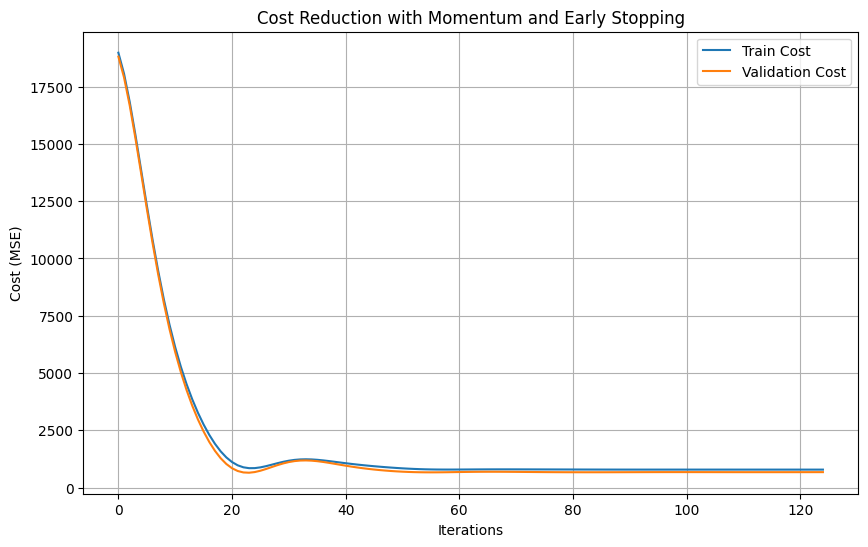

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(train_cost_hist, label='Train Cost')
plt.plot(val_cost_hist, label='Validation Cost')
plt.xlabel("Iterations")
plt.ylabel("Cost (MSE)")
plt.title("Cost Reduction with Momentum and Early Stopping")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
predictions_test_scaled = X_test.dot(theta_final)
predictions_test = predictions_test_scaled * 1000
y_test_orig = y_test * 1000

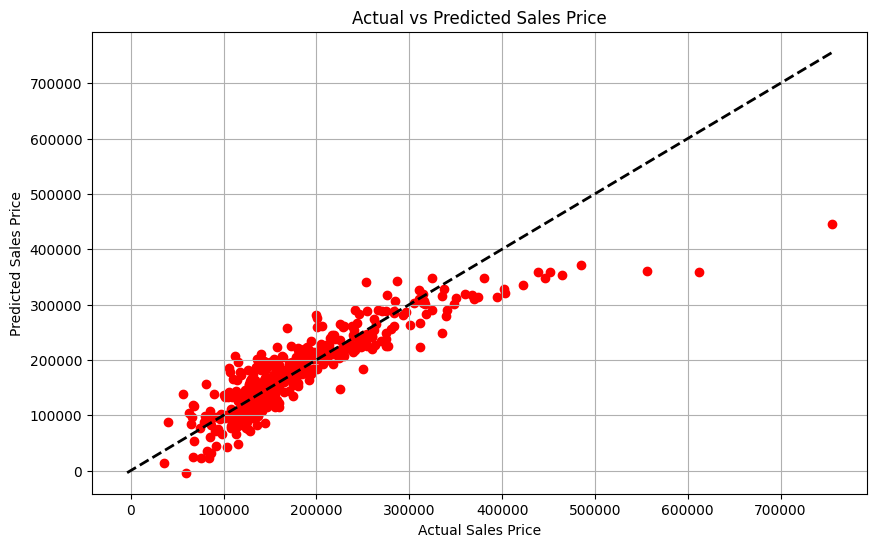

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_orig, predictions_test, color='red', marker='o')
plt.xlabel("Actual Sales Price")
plt.ylabel("Predicted Sales Price")
plt.title("Actual vs Predicted Sales Price")
min_price = min(y_test_orig.min(), predictions_test.min())
max_price = max(y_test_orig.max(), predictions_test.max())
plt.plot([min_price, max_price], [min_price, max_price], 'k--', lw=2)
plt.grid(True)
plt.show()

In [ ]:
def linear_regression_normal_equation(X, y):
    X_transpose = np.transpose(X)
    X_transpose_X = np.dot(X_transpose, X)
    X_transpose_y = np.dot(X_transpose, y)

    try:
        theta = np.linalg.solve(X_transpose_X, X_transpose_y)
        return theta
    except np.linalg.LinAlgError:
        return None


X_with_intercept = np.c_[np.ones((X.shape[0], 1)), X]

theta = linear_regression_normal_equation(X_with_intercept, y)
if theta is not None:
    print(theta)
else:
    print("Unable to compute theta. The matrix X_transpose_X is singular.")

def predict(X, theta):
    predictions = np.dot(X, theta)
    return predictions


X_test_with_intercept = np.c_[np.ones((X_test.shape[0], 1)), X_test]
predictions = predict(X_test_with_intercept, theta)
print("Predictions:", predictions)

plt.scatter(X, y, color='blue', label='Data Points')
plt.plot(X, predict(X_with_intercept, theta), color='red', label='Regression Line')
plt.scatter(X_test, predictions, color='green', marker='x', label='Predictions')
plt.title('Linear Regression using Normal Equation')
plt.xlabel('Feature (X)')
plt.ylabel('Target (y)')
plt.legend()
plt.grid()
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
r2score = r2_score(y_test_orig, predictions_test)
print("R2 Score:", r2score)

R2 Score: 0.7826498807502629


Using Scikit Learn

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = LinearRegression()
results=[]
model.fit(X_train, y_train)
predictions = model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
results.append({'MSE': mse, 'R2 Score': r2})

In [ ]:
print('MSE:', mse)
print('R2 Score:', r2)

MSE: 1538.3495118258384
R2 Score: 0.7795458810775904


In [ ]:
model = GradientBoostingRegressor()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

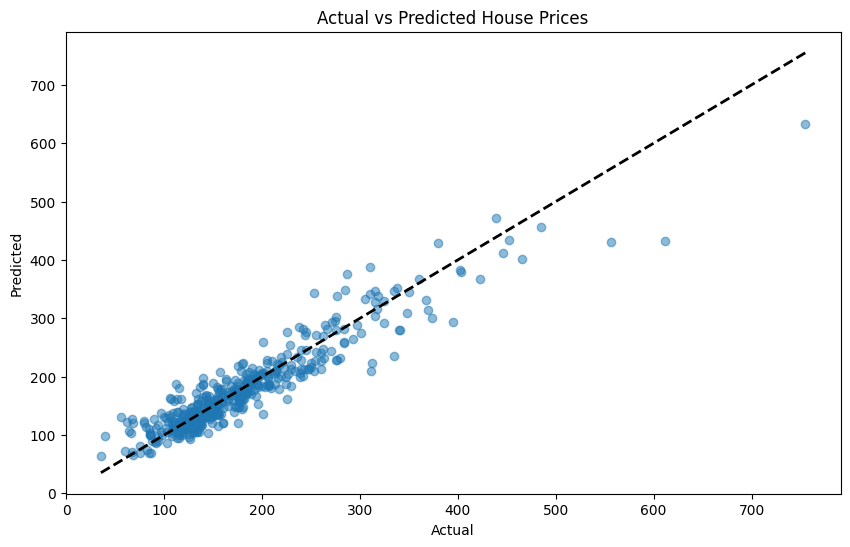

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted House Prices')
plt.show()